In [1]:
import pandas as pd
df_comp = pd.read_csv('computation-time.csv')
df_comm = pd.read_csv('communication-time.csv')

cluster_aliases = {'tuo': 'tuolumne'}
df_comp['cluster'] = df_comp['cluster'].replace(cluster_aliases)
df_comm['cluster'] = df_comm['cluster'].replace(cluster_aliases)

In [2]:
df_comp

,cluster,application_name,packages.dependencies.hip.version,Avg time/rank (exc)
0,tuolumne,amg2023,6.4.2,4.953036
1,tuolumne,amg2023,7.2.0,7.458068
2,tioga,amg2023,7.2.0,3.231351
3,tioga,amg2023,7.2.0,3.289163
4,tuolumne,amg2023,7.2.0,6.497000
...,...,...,...,...
75,tuolumne,lammps,6.4.2,14.389867
76,tuolumne,lammps,6.4.2,14.274439
77,tuolumne,lammps,6.4.2,14.315938
78,tuolumne,lammps,6.4.2,14.393852


In [3]:
df_comm

,cluster,application_name,packages.dependencies.hip.version,Avg time/rank (exc)
0,tuolumne,amg2023,6.4.2,0.605835
1,tuolumne,amg2023,7.2.0,1.192206
2,tioga,amg2023,7.2.0,0.470855
3,tioga,amg2023,7.2.0,0.599252
4,tuolumne,amg2023,7.2.0,1.845654
...,...,...,...,...
75,tuolumne,lammps,6.4.2,2.117400
76,tuolumne,lammps,6.4.2,2.545000
77,tuolumne,lammps,6.4.2,1.918700
78,tuolumne,lammps,6.4.2,2.109700


amg2023


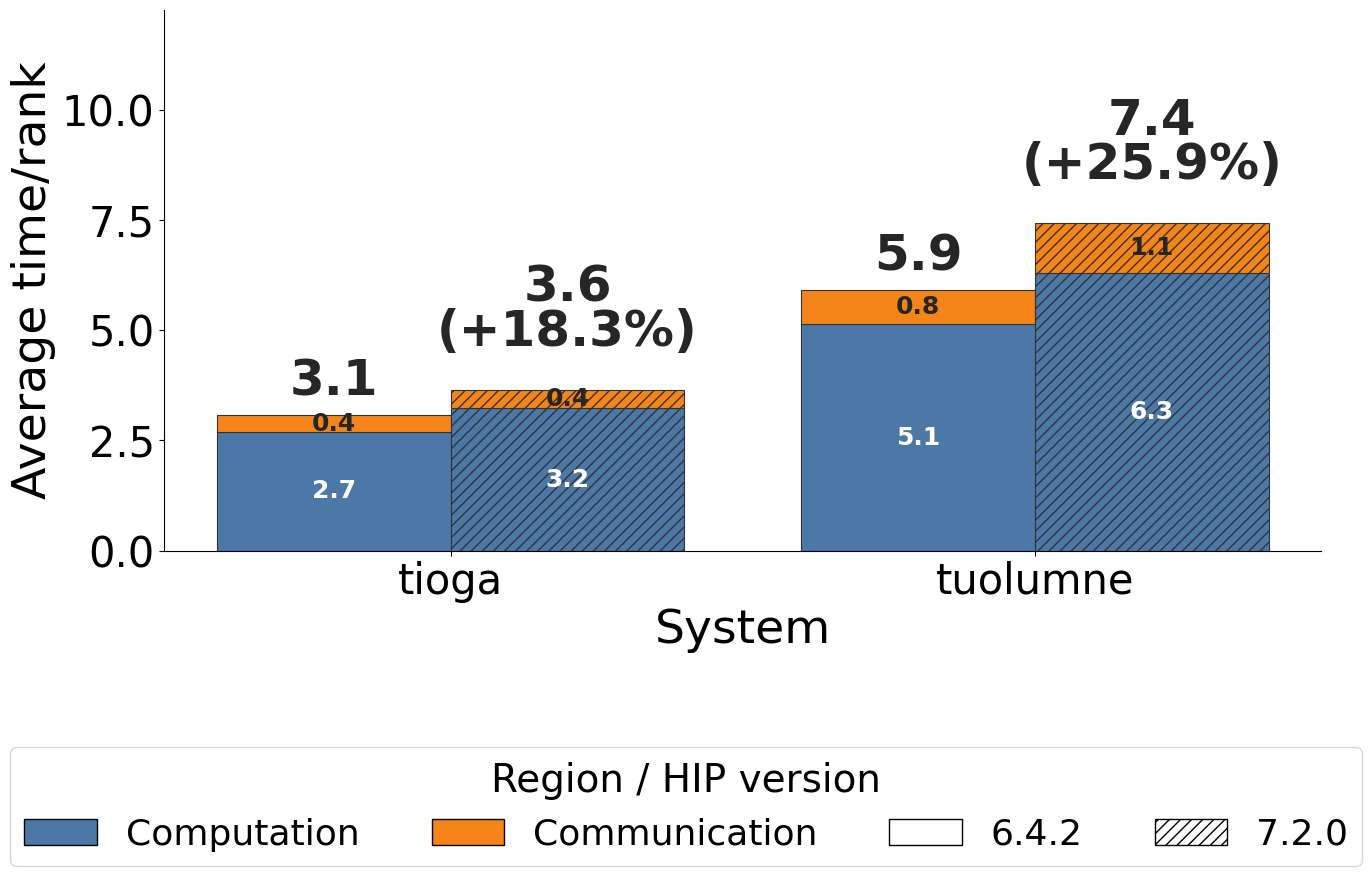

kripke


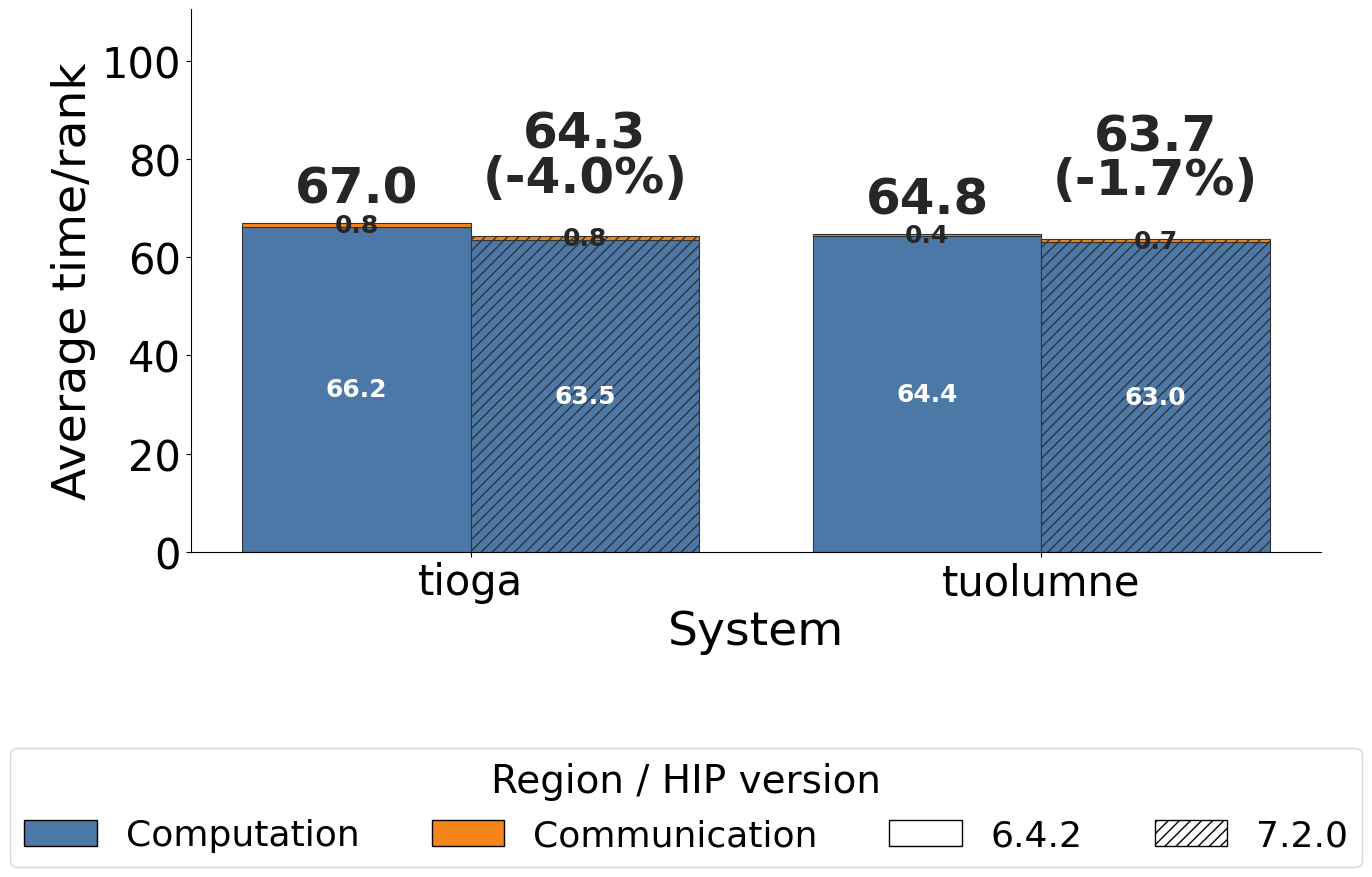

laghos


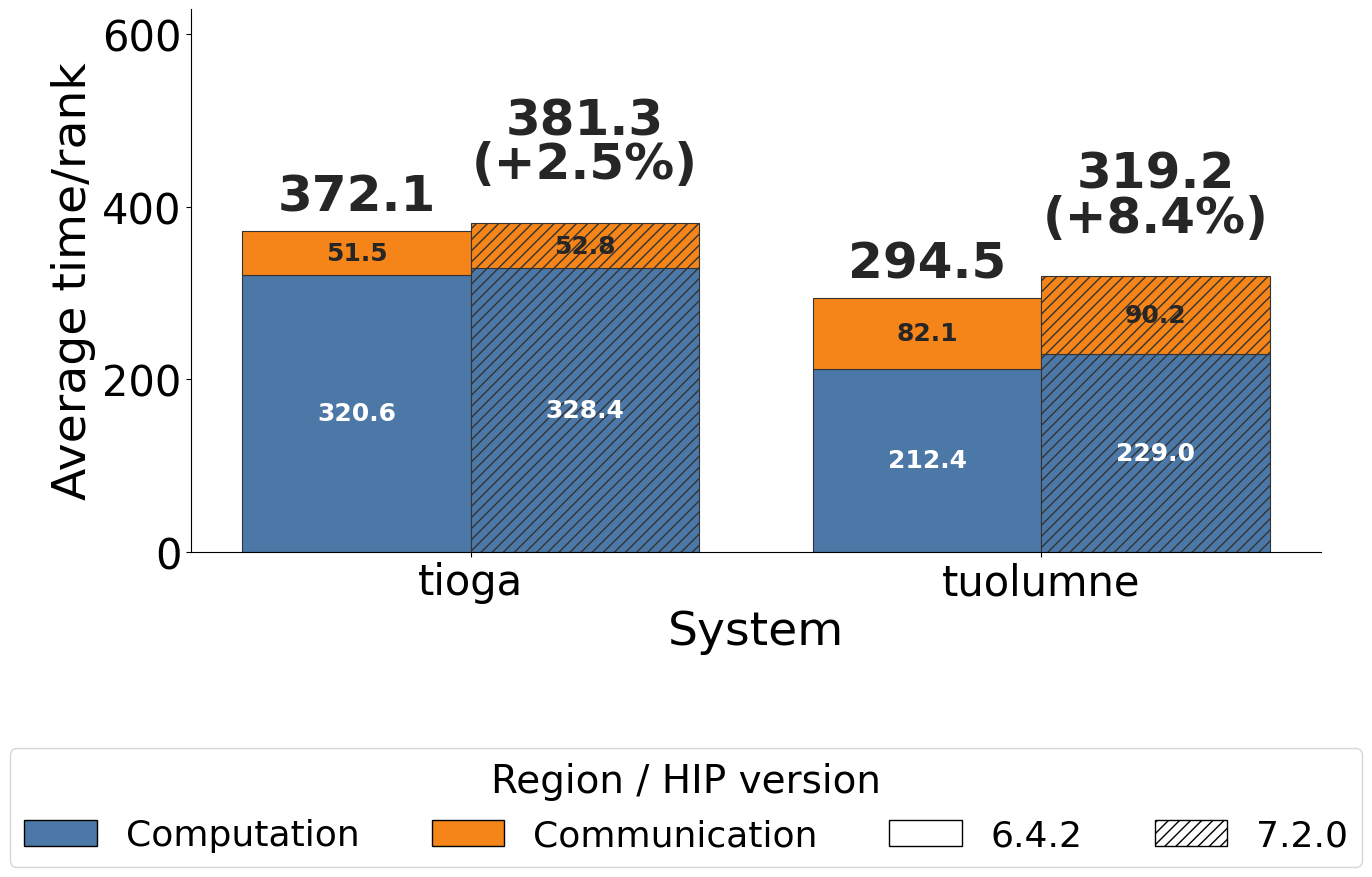

lammps


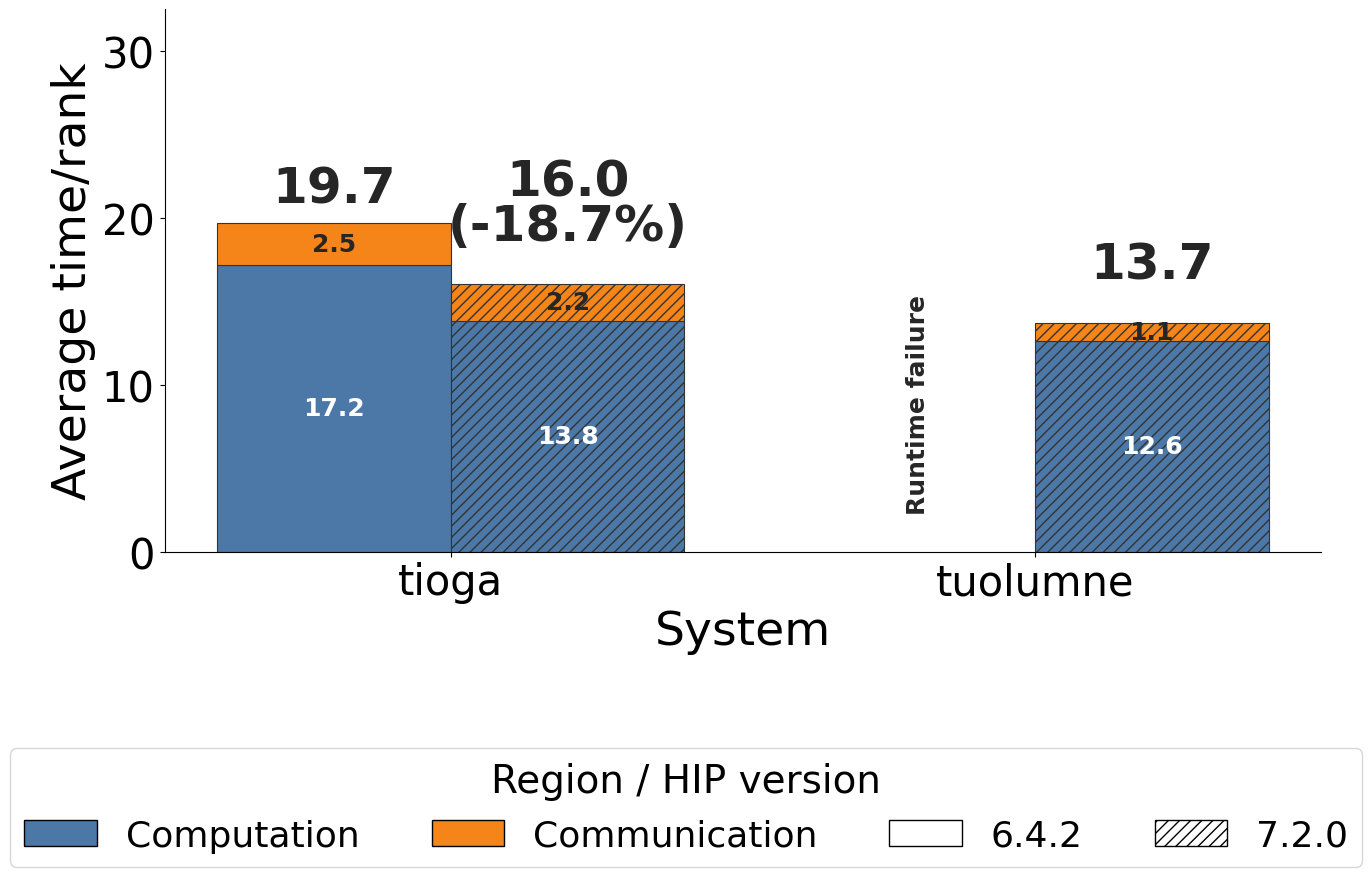

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch

value_col = 'Avg time/rank (exc)'
summary_stat = 'mean'  # use 'mean' for average
version_col = 'packages.dependencies.hip.version'
group_cols = ['cluster', 'application_name', version_col]

bar_df = (
    pd.concat(
        [df_comp.assign(region='Computation'), df_comm.assign(region='Communication')],
        ignore_index=True,
    )
    .groupby(group_cols + ['region'])[value_col]
    .agg(summary_stat)
    .unstack(fill_value=0)
    .reset_index()
)
for component in ['Computation', 'Communication']:
    if component not in bar_df:
        bar_df[component] = 0
bar_df['total'] = bar_df['Computation'] + bar_df['Communication']
bar_df[version_col] = bar_df[version_col].astype(str)
failure_label_col = 'failure_label'
bar_df[failure_label_col] = ''
runtime_failure_mask = (
    (bar_df['cluster'] == 'tuolumne')
    & (bar_df['application_name'] == 'lammps')
    & (bar_df[version_col] == '6.4.2')
)
bar_df.loc[runtime_failure_mask, ['Computation', 'Communication', 'total']] = 0
bar_df.loc[runtime_failure_mask, failure_label_col] = 'Runtime failure'

version_order = sorted(bar_df[version_col].astype(str).unique())
app_order = sorted(bar_df['application_name'].unique())
preferred_clusters = ['tioga', 'frontier', 'tuolumne']
cluster_order = [c for c in preferred_clusters if c in set(bar_df['cluster'])]
cluster_order += [c for c in sorted(bar_df['cluster'].unique()) if c not in cluster_order]

# sns.set_theme(style='whitegrid', context='talk')
axis_label_size = 34
tick_label_size = 30
legend_title_size = 28
legend_label_size = 26
total_label_size = 36
region_label_size = 18
region_colors = {'Computation': '#4C78A8', 'Communication': '#F58518'}
hatches = ['', '///', 'xxx', '...']
version_hatches = {version: hatches[i % len(hatches)] for i, version in enumerate(version_order)}
region_handles = [
    Patch(facecolor=color, edgecolor='black', label=region)
    for region, color in region_colors.items()
]
version_handles = [
    Patch(facecolor='white', edgecolor='black', hatch=version_hatches[version], label=version)
    for version in version_order
]

x = np.arange(len(cluster_order))
bar_width = 0.8 / len(version_order)
offsets = (np.arange(len(version_order)) - (len(version_order) - 1) / 2) * bar_width

for app in app_order:
    print(app)
    app_df = bar_df[bar_df['application_name'] == app]
    baseline_totals = (
        app_df[app_df[version_col] == version_order[0]]
        .set_index('cluster')
        .reindex(cluster_order, fill_value=0)['total']
    )
    fig, ax = plt.subplots(figsize=(13, 9))
    plot_max = app_df['total'].max()
    total_label_offset = plot_max * 0.03
    failure_label_y = plot_max * 0.45

    for version_idx, (offset, version) in enumerate(zip(offsets, version_order)):
        version_df = app_df[app_df[version_col] == version].set_index('cluster')
        version_df = version_df.reindex(cluster_order, fill_value=0)
        failure_labels = version_df[failure_label_col].replace(0, '').fillna('')
        failure_flags = failure_labels.astype(bool)
        xpos = x + offset

        comp_bars = ax.bar(
            xpos,
            version_df['Computation'],
            bar_width,
            color=region_colors['Computation'],
            edgecolor='0.2',
            linewidth=0.8,
            hatch=version_hatches[version],
        )
        comm_bars = ax.bar(
            xpos,
            version_df['Communication'],
            bar_width,
            bottom=version_df['Computation'],
            color=region_colors['Communication'],
            edgecolor='0.2',
            linewidth=0.8,
            hatch=version_hatches[version],
        )
        for bars in [comp_bars, comm_bars]:
            for bar, failed in zip(bars, failure_flags):
                if failed:
                    bar.set_visible(False)

        for xpos_value, failure_label in zip(xpos, failure_labels):
            if not failure_label:
                continue
            ax.text(
                xpos_value,
                failure_label_y,
                failure_label,
                ha='center',
                va='center',
                rotation=90,
                color='0.15',
                fontsize=region_label_size,
                fontweight='bold',
            )

        for bars, values, color in [
            (comp_bars, version_df['Computation'], 'white'),
            (comm_bars, version_df['Communication'], '0.15'),
        ]:
            for bar, value in zip(bars, values):
                if value == 0:
                    continue
                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    bar.get_y() + bar.get_height() / 2,
                    f'{value:.1f}',
                    ha='center',
                    va='center',
                    color=color,
                    fontsize=region_label_size,
                    fontweight='bold',
                )

        for bar, total, baseline_total in zip(comp_bars, version_df['total'], baseline_totals):
            if total == 0:
                continue
            total_label = f'{total:.1f}'
            if version_idx > 0 and baseline_total != 0:
                pct_change = (total - baseline_total) / baseline_total * 100
                total_label += f'\n({pct_change:+.1f}%)'
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                total + total_label_offset * (1 + version_idx * 2.5),
                total_label,
                ha='center',
                va='bottom',
                rotation=0,
                color='0.15',
                fontsize=total_label_size,
                fontweight='bold',
                linespacing=0.9,
            )

    fig.legend(
        handles=region_handles + version_handles,
        title='Region / HIP version',
        loc='lower center',
        bbox_to_anchor=(0.5, 0.01),
        ncol=len(region_handles) + len(version_handles),
        fontsize=legend_label_size,
        title_fontsize=legend_title_size,
    )
    ax.set_xticks(x)
    ax.set_xticklabels(cluster_order)
    ax.set_xlabel('System', fontsize=axis_label_size)
    # ax.set_ylabel(f'{summary_stat.title()} {value_col}', fontsize=axis_label_size)
    ax.set_ylabel(f'Average time/rank', fontsize=axis_label_size)
    ax.tick_params(axis='both', labelsize=tick_label_size)
    ax.set_ylim(0, plot_max * 1.65)
    sns.despine(ax=ax)
    fig.tight_layout(rect=[0, 0.25, 1, 1])
    safe_app = str(app).replace(' ', '_').replace('/', '-')
    fig.savefig(f'stacked_barchart_{safe_app}.png', dpi=300, bbox_inches='tight')
    plt.show()

In [5]:
# system_axis_label_size = axis_label_size * 2
# system_tick_label_size = tick_label_size * 2
# system_legend_title_size = legend_title_size * 2
# system_legend_label_size = legend_label_size * 2
# system_total_label_size = total_label_size * 2
# system_region_label_size = region_label_size * 2

# x = np.arange(len(app_order))
# bar_width = 0.8 / len(version_order)
# offsets = (np.arange(len(version_order)) - (len(version_order) - 1) / 2) * bar_width

# for cluster in cluster_order:
#     system_df = bar_df[bar_df['cluster'] == cluster]
#     if system_df.empty:
#         continue
#     print(cluster)

#     baseline_totals = (
#         system_df[system_df[version_col] == version_order[0]]
#         .set_index('application_name')
#         .reindex(app_order, fill_value=0)['total']
#     )
#     fig, ax = plt.subplots(figsize=(26, 18))
#     plot_max = system_df['total'].max()
#     total_label_offset = plot_max * 0.04
#     failure_label_y = plot_max * 0.45

#     for version_idx, (offset, version) in enumerate(zip(offsets, version_order)):
#         version_df = system_df[system_df[version_col] == version].set_index('application_name')
#         version_df = version_df.reindex(app_order, fill_value=0)
#         failure_labels = version_df[failure_label_col].replace(0, '').fillna('')
#         failure_flags = failure_labels.astype(bool)
#         xpos = x + offset

#         comp_bars = ax.bar(
#             xpos,
#             version_df['Computation'],
#             bar_width,
#             color=region_colors['Computation'],
#             edgecolor='0.2',
#             linewidth=1.6,
#             hatch=version_hatches[version],
#         )
#         comm_bars = ax.bar(
#             xpos,
#             version_df['Communication'],
#             bar_width,
#             bottom=version_df['Computation'],
#             color=region_colors['Communication'],
#             edgecolor='0.2',
#             linewidth=1.6,
#             hatch=version_hatches[version],
#         )
#         for bars in [comp_bars, comm_bars]:
#             for bar, failed in zip(bars, failure_flags):
#                 if failed:
#                     bar.set_visible(False)

#         for xpos_value, failure_label in zip(xpos, failure_labels):
#             if not failure_label:
#                 continue
#             ax.text(
#                 xpos_value,
#                 failure_label_y,
#                 failure_label,
#                 ha='center',
#                 va='center',
#                 rotation=90,
#                 color='0.15',
#                 fontsize=system_region_label_size,
#                 fontweight='bold',
#             )

#         for bars, values, color in [
#             (comp_bars, version_df['Computation'], 'white'),
#             (comm_bars, version_df['Communication'], '0.15'),
#         ]:
#             for bar, value in zip(bars, values):
#                 if value == 0:
#                     continue
#                 ax.text(
#                     bar.get_x() + bar.get_width() / 2,
#                     bar.get_y() + bar.get_height() / 2,
#                     f'{value:.1f}',
#                     ha='center',
#                     va='center',
#                     color=color,
#                     fontsize=system_region_label_size,
#                     fontweight='bold',
#                 )

#         for bar, total, baseline_total in zip(comp_bars, version_df['total'], baseline_totals):
#             if total == 0:
#                 continue
#             total_label = f'{total:.1f}'
#             if version_idx > 0 and baseline_total != 0:
#                 pct_change = (total - baseline_total) / baseline_total * 100
#                 total_label += f'\n({pct_change:+.1f}%)'
#             ax.text(
#                 bar.get_x() + bar.get_width() / 2,
#                 total + total_label_offset * (1 + version_idx * 2.5),
#                 total_label,
#                 ha='center',
#                 va='bottom',
#                 color='0.15',
#                 fontsize=system_total_label_size,
#                 fontweight='bold',
#                 linespacing=0.9,
#             )

#     fig.legend(
#         handles=region_handles + version_handles,
#         title='Region / HIP version',
#         loc='lower center',
#         bbox_to_anchor=(0.5, 0.01),
#         ncol=len(region_handles) + len(version_handles),
#         fontsize=system_legend_label_size,
#         title_fontsize=system_legend_title_size,
#     )
#     ax.set_xticks(x)
#     ax.set_xticklabels(app_order, rotation=20, ha='right')
#     ax.set_xlabel('Benchmark', fontsize=system_axis_label_size)
#     # ax.set_ylabel(f'{summary_stat.title()} {value_col}', fontsize=system_axis_label_size)
#     ax.set_ylabel(f'Average time/rank', fontsize=system_axis_label_size)
#     ax.tick_params(axis='both', labelsize=system_tick_label_size)
#     ax.set_ylim(0, plot_max * 1.85)
#     sns.despine(ax=ax)
#     fig.tight_layout(rect=[0, 0.25, 1, 1])
#     safe_cluster = str(cluster).replace(' ', '_').replace('/', '-')
#     fig.savefig(f'stacked_barchart_by_system_{safe_cluster}.png', dpi=300, bbox_inches='tight')
#     plt.show()